# MIT-BIH AFDB — Baseline Model (Lead 2 Only)

**Dataset:** MIT-BIH Atrial Fibrillation Database  
**Task:** Binary classification — AFib vs Non-AFib  
**Model:** KanResWideX (baseline architecture, 1 channel — Lead 2 / ECG2)  
**Split:** 60% train / 20% val / 20% test (patient-level, same seed as Lead 1 baseline)


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from collections import Counter
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Model Definition

In [3]:
class KanResInit(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride)
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2)
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        return x

class KanResModule(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2, padding='same')
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = out + identity
        return out

class KanResWideX(nn.Module):
    def __init__(self, input_channels=1, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(kernel_size=2)
        self.res_modules = nn.ModuleList([
            KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)
        ])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)

    def forward(self, x):
        x = self.init_block(x)
        x = self.pool(x)
        for res_module in self.res_modules:
            x = res_module(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

print("Model defined.")
total_params = sum(p.numel() for p in KanResWideX().parameters())
print(f"Total parameters: {total_params:,}")

Model defined.
Total parameters: 1,647,714


## 3. Configuration

In [5]:
class Config:
    data_dir = "/home/issar/files"
    fs = 250
    channel = 1                           # ECG2 (Lead 2) — channel index 1
    window_seconds = 4
    window_size = fs * window_seconds
    stride_seconds = 2
    stride_size = fs * stride_seconds
    skip_records = ["00735", "03665"]
    num_classes = 2
    batch_size = 64
    num_epochs = 30
    learning_rate = 1e-3
    test_size = 0.2
    val_size = 0.25
    random_seed = 42

config = Config()
assert os.path.exists(config.data_dir), f"Data path not found: {config.data_dir}"
print(f"Data path OK: {config.data_dir}")
print(f"Channel: {config.channel} (Lead 2 / ECG2)")
print(f"Window: {config.window_size} samples ({config.window_seconds}s)")
print(f"Stride: {config.stride_size} samples ({config.stride_seconds}s)")
print(f"Split: {1 - config.test_size:.0%} train+val / {config.test_size:.0%} test, then {config.val_size:.0%} of train for val")

Data path OK: /home/issar/files
Channel: 1 (Lead 2 / ECG2)
Window: 1000 samples (4s)
Stride: 500 samples (2s)
Split: 80% train+val / 20% test, then 25% of train for val


## 4. Data Loading & Windowing (Lead 2 Only)

In [6]:
def get_record_list(data_dir):
    records = sorted(set(os.path.splitext(f)[0] for f in os.listdir(data_dir) if f.endswith(".dat")))
    print(f"Found {len(records)} records with signal files")
    return records

def load_rhythm_annotations(data_dir, record_name):
    try:
        ann = wfdb.rdann(os.path.join(data_dir, record_name), "atr")
    except Exception as e:
        print(f"  Warning: Could not read annotations for {record_name}: {e}")
        return []
    try:
        record = wfdb.rdheader(os.path.join(data_dir, record_name))
        total_samples = record.sig_len
    except Exception:
        total_samples = 10 * 3600 * config.fs
    segments = []
    for i in range(len(ann.sample)):
        start = ann.sample[i]
        end = ann.sample[i + 1] if i + 1 < len(ann.sample) else total_samples
        label = ann.aux_note[i] if ann.aux_note[i] else None
        if label:
            label = label.strip().strip("(").strip()
            if label in ("AFIB", "AF"): label = "AF"
            elif label == "AFL": label = "AFL"
            elif label == "J": label = "J"
            else: label = "N"
        if label and end > start:
            segments.append((start, end, label))
    return segments

def create_windows_for_record(data_dir, record_name, config):
    try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_name))
        signal = record.p_signal
        # Use Lead 2 (channel index 1)
        if signal.shape[1] <= config.channel:
            print(f"  Warning: {record_name} has only {signal.shape[1]} channels, duplicating channel 0")
            lead_signal = signal[:, 0]
        else:
            lead_signal = signal[:, config.channel]
    except Exception as e:
        print(f"  Warning: Could not read signal for {record_name}: {e}")
        return None, None, None

    segments = load_rhythm_annotations(data_dir, record_name)
    if not segments:
        return None, None, None

    total_samples = len(lead_signal)
    sample_labels = np.zeros(total_samples, dtype=np.int64)
    afib_events = 0
    for start, end, rhythm in segments:
        if rhythm == "AF":
            sample_labels[max(start, 0):min(end, total_samples)] = 1
            afib_events += 1

    windows, labels = [], []
    win_start = 0
    while win_start + config.window_size <= total_samples:
        win_end = win_start + config.window_size
        win_signal = lead_signal[win_start:win_end].copy()

        if np.any(np.isnan(win_signal)):
            win_start += config.stride_size
            continue

        std = np.std(win_signal)
        if std < 1e-6:
            win_start += config.stride_size
            continue
        win_signal = (win_signal - np.mean(win_signal)) / std

        windows.append(win_signal)
        afib_ratio = np.mean(sample_labels[win_start:win_end])
        labels.append(1 if afib_ratio > 0.5 else 0)
        win_start += config.stride_size

    if not windows:
        return None, None, None

    windows = np.array(windows, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    stats = {"afib_events": afib_events, "total_windows": len(labels),
             "afib_windows": int(np.sum(labels == 1)), "non_afib_windows": int(np.sum(labels == 0))}
    return windows, labels, stats

print("Functions defined.")

Functions defined.


## 5. Load All Records

In [7]:
records = get_record_list(config.data_dir)
records = [r for r in records if r not in config.skip_records]
all_record_data = {}
total_stats = {"afib_events": 0, "total_windows": 0, "afib_windows": 0, "non_afib_windows": 0}

print(f"\n{'Record':<10} {'AFib Events':<15} {'Total Win':<12} {'AFib Win':<12} {'Non-AFib Win':<15}")
print("-" * 65)
for record_name in records:
    windows, labels, stats = create_windows_for_record(config.data_dir, record_name, config)
    if windows is not None:
        all_record_data[record_name] = (windows, labels)
        for key in total_stats:
            total_stats[key] += stats[key]
        print(f"{record_name:<10} {stats['afib_events']:<15} {stats['total_windows']:<12} {stats['afib_windows']:<12} {stats['non_afib_windows']:<15}")
print("-" * 65)
print(f"{'TOTAL':<10} {total_stats['afib_events']:<15} {total_stats['total_windows']:<12} {total_stats['afib_windows']:<12} {total_stats['non_afib_windows']:<15}")
print(f"\nRecords loaded: {len(all_record_data)}")

Found 23 records with signal files

Record     AFib Events     Total Win    AFib Win     Non-AFib Win   
-----------------------------------------------------------------
04015      7               18410        119          18291          
04043      82              18407        3966         14441          
04048      7               18410        180          18230          
04126      7               18410        688          17722          
04746      5               18410        9776         8634           
04908      8               18410        1541         16869          
04936      36              18410        13281        5129           
05091      8               18410        41           18369          
05121      20              18410        11604        6806           
05261      11              18410        242          18168          
06426      26              18410        17559        851            
06453      6               16649        187          16462          
0

## 6. Train / Val / Test Split

In [8]:
record_names = sorted(all_record_data.keys())

train_records, test_records = train_test_split(
    record_names, test_size=config.test_size, random_state=config.random_seed
)
train_records, val_records = train_test_split(
    train_records, test_size=config.val_size, random_state=config.random_seed
)

def merge_records(record_list):
    w_list, l_list = [], []
    for r in record_list:
        w, l = all_record_data[r]
        w_list.append(w)
        l_list.append(l)
    return np.concatenate(w_list), np.concatenate(l_list)

X_train, y_train = merge_records(train_records)
X_val, y_val = merge_records(val_records)
X_test, y_test = merge_records(test_records)

print(f"Train records ({len(train_records)}): {train_records}")
print(f"Val records   ({len(val_records)}):  {val_records}")
print(f"Test records  ({len(test_records)}):  {test_records}")
print(f"\nTrain: {len(y_train):,} windows (AFib: {np.sum(y_train==1):,}, Non-AFib: {np.sum(y_train==0):,})")
print(f"Val:   {len(y_val):,} windows (AFib: {np.sum(y_val==1):,}, Non-AFib: {np.sum(y_val==0):,})")
print(f"Test:  {len(y_test):,} windows (AFib: {np.sum(y_test==1):,}, Non-AFib: {np.sum(y_test==0):,})")

Train records (13): ['05091', '08378', '07859', '08434', '07162', '08219', '04936', '04048', '08455', '04126', '07910', '06426', '08405']
Val records   (5):  ['06995', '04043', '04746', '06453', '04908']
Test records  (5):  ['07879', '05261', '04015', '05121', '08215']

Train: 239,318 windows (AFib: 106,060, Non-AFib: 133,258)
Val:   90,286 windows (AFib: 24,147, Non-AFib: 66,139)
Test:  92,050 windows (AFib: 37,902, Non-AFib: 54,148)


## 7. Dataset & DataLoaders

In [9]:
class ECGDataset(Dataset):
    def __init__(self, windows, labels):
        self.windows = torch.FloatTensor(windows).unsqueeze(1)  # (N, 1, 1000)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.windows[idx], self.labels[idx]

train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=config.batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 3740
Val batches:   1411
Test batches:  1439


## 8. Model, Loss, Optimizer

In [10]:
model = KanResWideX(input_channels=1, output_size=config.num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: KanResWideX (Lead 2 only)")
print(f"Total parameters: {total_params:,}")

class_counts = Counter(y_train.tolist())
class_weights = torch.FloatTensor([
    len(y_train) / (config.num_classes * class_counts[i])
    for i in range(config.num_classes)
]).to(device)
print(f"Class weights: {class_weights.cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

Model: KanResWideX (Lead 2 only)
Total parameters: 1,647,714
Class weights: [0.8979498 1.1282198]


## 9. Training & Evaluation Functions

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    return (running_loss / total, correct / total,
            np.array(all_targets), np.array(all_preds), np.array(all_probs))

print("Functions defined.")

Functions defined.


## 10. Training Loop

In [12]:
print(f"Training for {config.num_epochs} epochs...\n")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Time':<8}")
print("-" * 66)

best_val_loss = float("inf")
best_model_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

total_start = time.time()

for epoch in range(1, config.num_epochs + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    epoch_time = time.time() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    note = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        note = " *"

    print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f} {epoch_time:<.0f}s{note}")

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time/60:.1f} minutes")
print(f"Best val loss: {best_val_loss:.4f}")

Training for 30 epochs...

Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Time    
------------------------------------------------------------------
1        0.0497       0.9832       1.4467       0.6703       100s *
2        0.0229       0.9930       1.4289       0.5901       95s *
3        0.0173       0.9945       1.1259       0.7375       95s *
4        0.0149       0.9953       0.7873       0.7708       95s *
5        0.0122       0.9961       1.1010       0.6987       95s
6        0.0109       0.9963       0.7376       0.7890       95s *
7        0.0096       0.9967       1.3016       0.6629       95s
8        0.0086       0.9970       1.0138       0.7097       95s
9        0.0077       0.9971       1.0789       0.7895       95s
10       0.0070       0.9975       1.1485       0.7466       96s
11       0.0043       0.9984       1.5146       0.7220       94s
12       0.0038       0.9986       1.7553       0.7032       94s
13       0.0033       0.9988       1.6572    

## 11. Training Curves

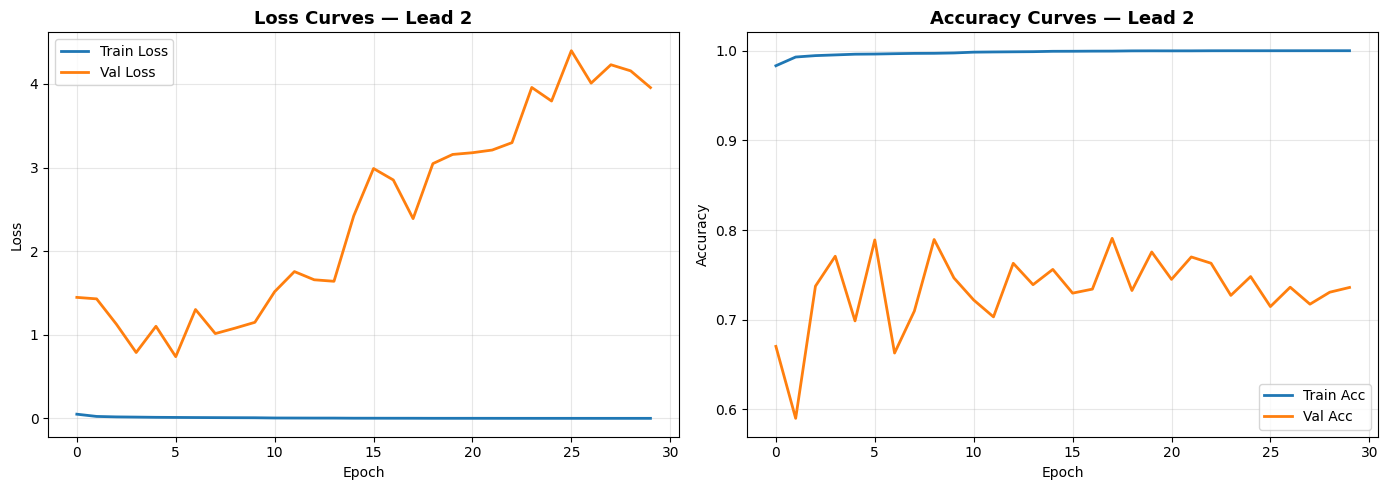

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history["train_loss"], label="Train Loss", linewidth=2)
ax.plot(history["val_loss"], label="Val Loss", linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Curves — Lead 2", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history["train_acc"], label="Train Acc", linewidth=2)
ax.plot(history["val_acc"], label="Val Acc", linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves — Lead 2", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Test Set Evaluation

In [14]:
# Load best model
model.load_state_dict(best_model_state)
test_loss, test_acc, test_targets, test_preds, test_probs = evaluate(model, test_loader, criterion, device)

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# All metrics
acc = accuracy_score(test_targets, test_preds)
prec = precision_score(test_targets, test_preds, pos_label=1, zero_division=0)
rec = recall_score(test_targets, test_preds, pos_label=1, zero_division=0)
f1 = f1_score(test_targets, test_preds, pos_label=1, zero_division=0)
mcc = matthews_corrcoef(test_targets, test_preds)
auroc = roc_auc_score(test_targets, test_probs)
auprc = average_precision_score(test_targets, test_probs)
brier = brier_score_loss(test_targets, test_probs)

# ECE and MCE
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
ece, mce = 0.0, 0.0
for i in range(n_bins):
    if i < n_bins - 1:
        mask = (test_probs >= bin_boundaries[i]) & (test_probs < bin_boundaries[i + 1])
    else:
        mask = (test_probs >= bin_boundaries[i]) & (test_probs <= bin_boundaries[i + 1])
    bin_count = mask.sum()
    if bin_count > 0:
        bin_acc = test_targets[mask].mean()
        bin_conf = test_probs[mask].mean()
        cal_error = abs(bin_acc - bin_conf)
        ece += (bin_count / len(test_targets)) * cal_error
        mce = max(mce, cal_error)

print("=" * 60)
print("TEST SET RESULTS — Lead 2 Only (ECG2)")
print("=" * 60)
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1:         {f1:.4f}")
print(f"  MCC:        {mcc:.4f}")
print(f"  AUROC:      {auroc:.4f}")
print(f"  AUPRC:      {auprc:.4f}")
print(f"  Brier:      {brier:.4f}")
print(f"  ECE:        {ece:.4f}")
print(f"  MCE:        {mce:.4f}")
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print()
print(classification_report(test_targets, test_preds, target_names=["Non-AFib", "AFib"]))

TEST SET RESULTS — Lead 2 Only (ECG2)
  Accuracy:   0.5848
  Precision:  0.4958
  Recall:     0.4910
  F1:         0.4934
  MCC:        0.1416
  AUROC:      0.5606
  AUPRC:      0.5513
  Brier:      0.3623
  ECE:        0.3402
  MCE:        0.4892
  TN=35221  FP=18927  FN=19293  TP=18609

              precision    recall  f1-score   support

    Non-AFib       0.65      0.65      0.65     54148
        AFib       0.50      0.49      0.49     37902

    accuracy                           0.58     92050
   macro avg       0.57      0.57      0.57     92050
weighted avg       0.58      0.58      0.58     92050



## 13. Confusion Matrix

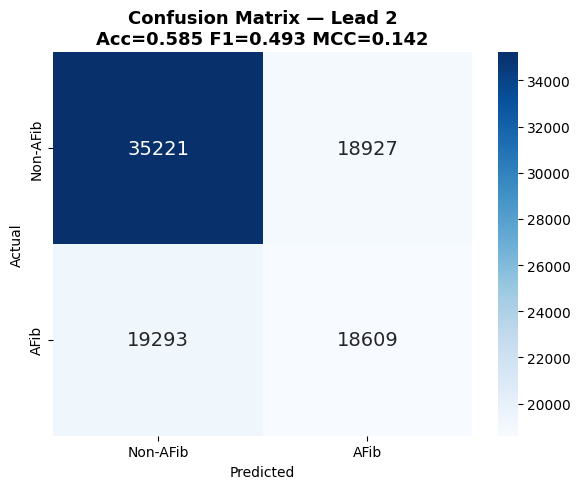

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-AFib", "AFib"], yticklabels=["Non-AFib", "AFib"],
            ax=ax, annot_kws={"size": 14})
ax.set_title(f"Confusion Matrix — Lead 2\nAcc={acc:.3f} F1={f1:.3f} MCC={mcc:.3f}", fontsize=13, fontweight='bold')
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 14. ROC Curve

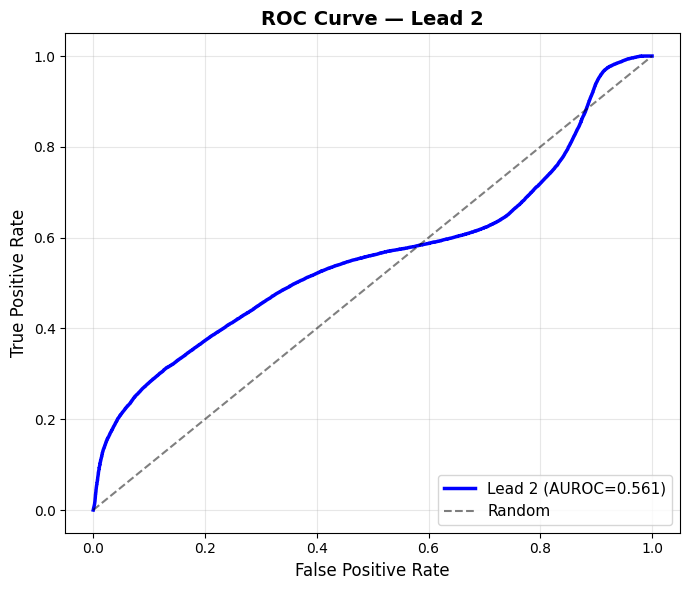

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
fpr, tpr, _ = roc_curve(test_targets, test_probs)
ax.plot(fpr, tpr, color='blue', linewidth=2.5, label=f'Lead 2 (AUROC={auroc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Lead 2', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Precision-Recall Curve

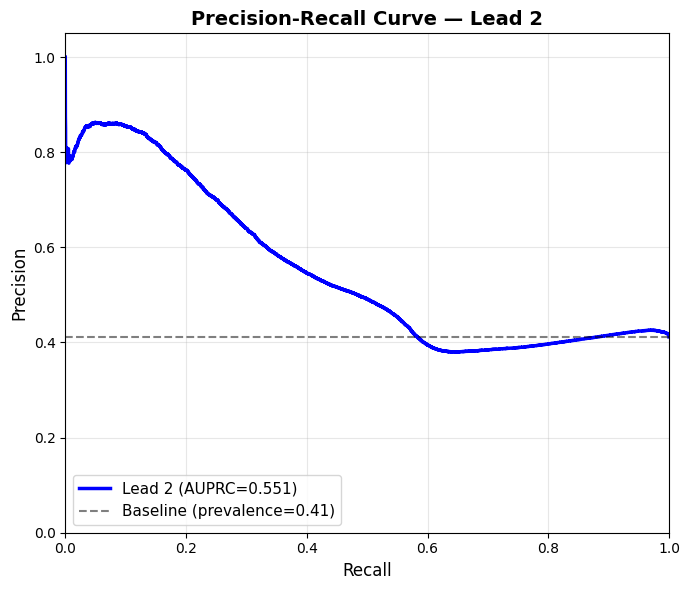

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
prec_c, rec_c, _ = precision_recall_curve(test_targets, test_probs)
ax.plot(rec_c, prec_c, color='blue', linewidth=2.5, label=f'Lead 2 (AUPRC={auprc:.3f})')
baseline = np.mean(test_targets)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Lead 2', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 16. Calibration Plot

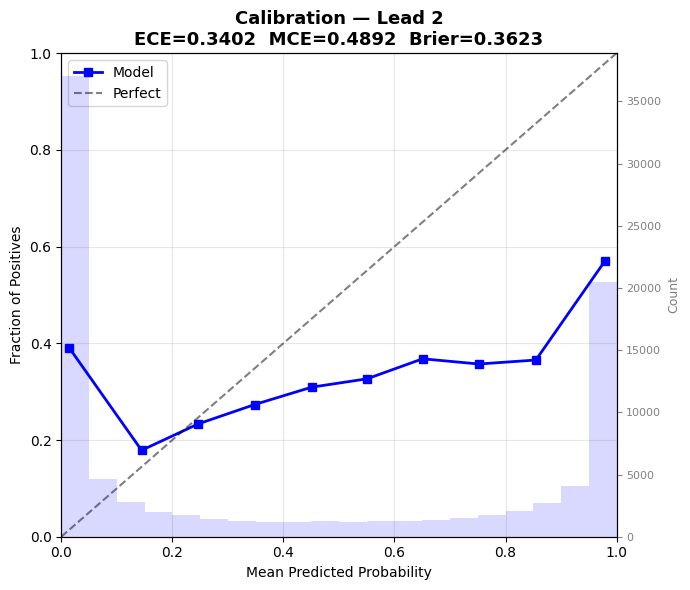

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
fraction_pos, mean_predicted = calibration_curve(test_targets, test_probs, n_bins=10, strategy='uniform')
ax.plot(mean_predicted, fraction_pos, 's-', color='blue', linewidth=2, markersize=6, label='Model')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax2 = ax.twinx()
ax2.hist(test_probs, bins=20, range=(0, 1), alpha=0.15, color='blue')
ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
ax2.tick_params(axis='y', labelsize=8, colors='gray')
ax.set_title(f"Calibration — Lead 2\nECE={ece:.4f}  MCE={mce:.4f}  Brier={brier:.4f}", fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Predicted Probability Distribution

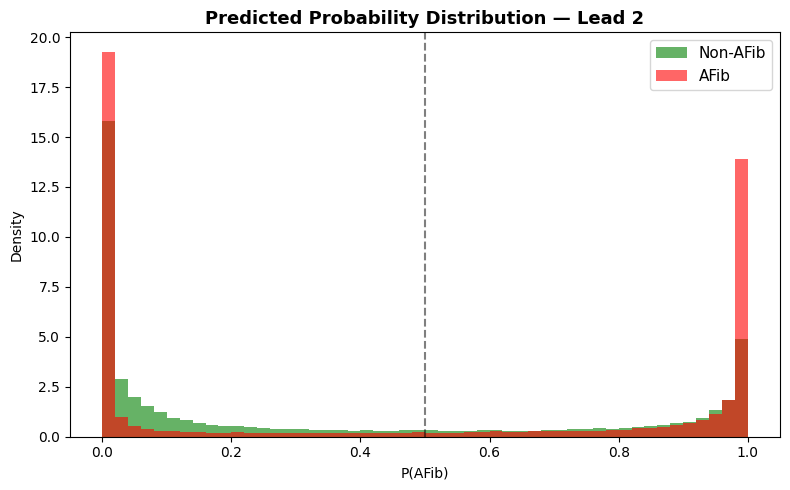

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
mask_neg = test_targets == 0
mask_pos = test_targets == 1
ax.hist(test_probs[mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Non-AFib', density=True)
ax.hist(test_probs[mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax.set_title("Predicted Probability Distribution — Lead 2", fontsize=13, fontweight='bold')
ax.set_xlabel("P(AFib)"); ax.set_ylabel("Density")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 18. Summary

In [20]:
print("=" * 60)
print("SUMMARY — Lead 2 Only (ECG2)")
print("=" * 60)
print(f"  Model:      KanResWideX (baseline, 1 channel)")
print(f"  Input:      Lead 2 / ECG2 (channel index 1)")
print(f"  Window:     {config.window_size} samples ({config.window_seconds}s)")
print(f"  Stride:     {config.stride_size} samples ({config.stride_seconds}s)")
print(f"  Epochs:     {config.num_epochs}")
print(f"  Best epoch: val_loss={best_val_loss:.4f}")
print(f"  Training:   {total_time/60:.1f} minutes")
print(f"\n  Test Results:")
print(f"    Accuracy:  {acc:.4f}")
print(f"    Precision: {prec:.4f}")
print(f"    Recall:    {rec:.4f}")
print(f"    F1:        {f1:.4f}")
print(f"    MCC:       {mcc:.4f}")
print(f"    AUROC:     {auroc:.4f}")
print(f"    AUPRC:     {auprc:.4f}")
print(f"    Brier:     {brier:.4f}")
print(f"    ECE:       {ece:.4f}")
print(f"    MCE:       {mce:.4f}")
print(f"    TN={tn}  FP={fp}  FN={fn}  TP={tp}")

SUMMARY — Lead 2 Only (ECG2)
  Model:      KanResWideX (baseline, 1 channel)
  Input:      Lead 2 / ECG2 (channel index 1)
  Window:     1000 samples (4s)
  Stride:     500 samples (2s)
  Epochs:     30
  Best epoch: val_loss=0.7376
  Training:   47.6 minutes

  Test Results:
    Accuracy:  0.5848
    Precision: 0.4958
    Recall:    0.4910
    F1:        0.4934
    MCC:       0.1416
    AUROC:     0.5606
    AUPRC:     0.5513
    Brier:     0.3623
    ECE:       0.3402
    MCE:       0.4892
    TN=35221  FP=18927  FN=19293  TP=18609
